# 🧠 Brain Tumor Detection


In [1]:
# ==========================================
# CELL 1 — IMPORTS
# ==========================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, RandomFlip, RandomRotation, RandomZoom
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


 Loaded  : 253 images
 Skipped : 0 unreadable files

--- Class Distribution ---
label
1    155
0     98
Name: count, dtype: int64


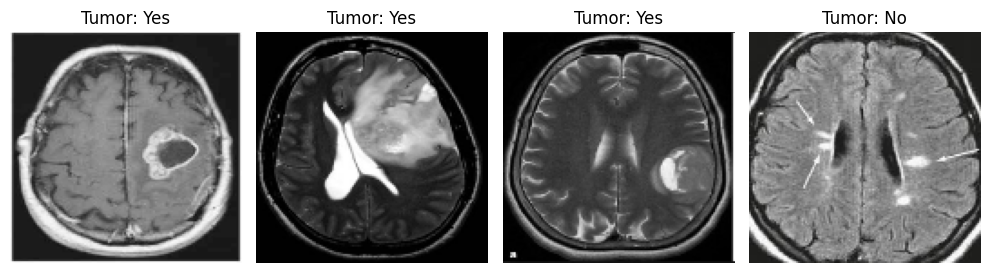

In [2]:
# ==========================================
# CELL 2 — LOAD DATA (with safe imread check)
# ==========================================
DATA_DIR   = 'brain_tumor_dataset'
CATEGORIES = ['no', 'yes']
IMG_SIZE   = 128

data = []
skipped = 0

for category in CATEGORIES:
    path      = os.path.join(DATA_DIR, category)
    class_num = CATEGORIES.index(category)

    for img_name in os.listdir(path):
        img_path  = os.path.join(path, img_name)
        img_array = cv2.imread(img_path)

        
        if img_array is None:
            skipped += 1
            continue

        new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
        data.append([new_array, class_num])

print(f' Loaded  : {len(data)} images')
print(f' Skipped : {skipped} unreadable files')

df_data = pd.DataFrame(data, columns=['image_matrix', 'label'])
print('\n--- Class Distribution ---')
print(df_data['label'].value_counts())


plt.figure(figsize=(10, 3))
for i in range(4):
    plt.subplot(1, 4, i+1)
    sample = data[np.random.randint(0, len(data))]
    plt.imshow(cv2.cvtColor(sample[0], cv2.COLOR_BGR2RGB))
    plt.title('Tumor: Yes' if sample[1] == 1 else 'Tumor: No')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [3]:
# ==========================================
# CELL 3 — DUPLICATE REMOVAL
# ==========================================
df_data['image_flat'] = df_data['image_matrix'].apply(lambda x: x.flatten().tobytes())

num_duplicates = df_data.duplicated(subset=['image_flat']).sum()
print(f' Duplicates found : {num_duplicates}  ({(num_duplicates/len(df_data))*100:.2f}%)')

if num_duplicates > 0:
    df_data = df_data.drop_duplicates(subset=['image_flat'])
    print(f' After removal    : {len(df_data)} images')
else:
    print(' No duplicates found.')

# Rebuild X, y
X = np.array(df_data['image_matrix'].tolist(), dtype='float32')  
y = df_data['label'].values
print(f'X shape: {X.shape}  |  y shape: {y.shape}')

 Duplicates found : 25  (9.88%)
 After removal    : 228 images
X shape: (228, 128, 128, 3)  |  y shape: (228,)


In [4]:
# ==========================================
# CELL 4 — MISSING VALUES & OUTLIERS
# ==========================================

# --- Missing values ---
total_nan = np.isnan(X).sum()
print(f'NaN pixel values: {total_nan}')
if total_nan > 0:
    X = np.nan_to_num(X, nan=np.nanmean(X))
    print(' NaNs replaced with mean.')
else:
    print(' No NaN values.')


mean_intensities  = X.mean(axis=(1, 2, 3))
outlier_indices   = np.where((mean_intensities < 10) | (mean_intensities > 245))[0]
print(f'Outlier images   : {len(outlier_indices)}')

if len(outlier_indices) > 0:
    X = np.delete(X, outlier_indices, axis=0)
    y = np.delete(y, outlier_indices, axis=0)
    print(f' Outliers removed. New shape: {X.shape}')
else:
    print(' No extreme outliers.')

NaN pixel values: 0
 No NaN values.
Outlier images   : 0
 No extreme outliers.


C:\Users\omar mohamed\AppData\Local\Temp\ipykernel_13004\4036162945.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette=['#4CAF50', '#FF5252'])


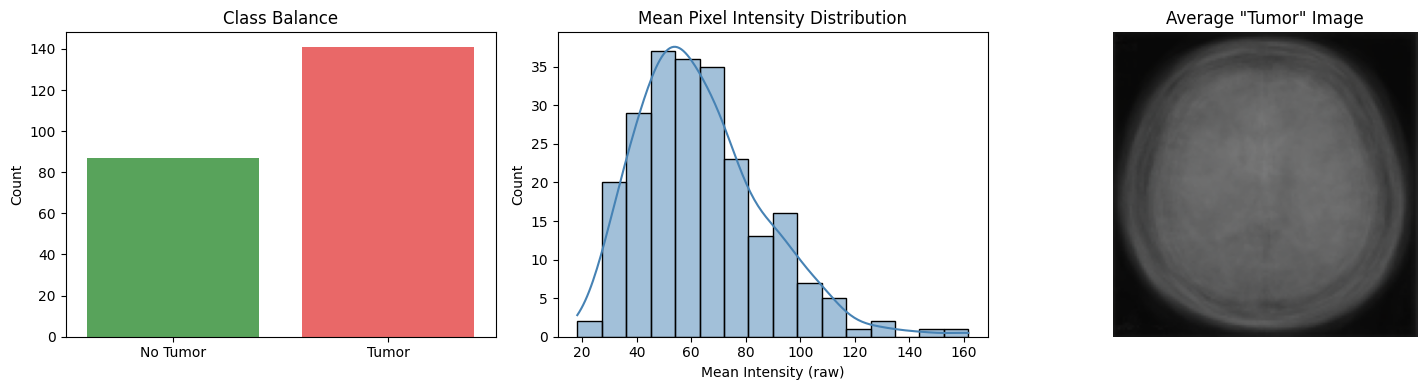

In [5]:
# ==========================================
# CELL 5 — EDA VISUALIZATIONS
# ==========================================
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.countplot(x=y, palette=['#4CAF50', '#FF5252'])
plt.xticks([0, 1], ['No Tumor', 'Tumor'])
plt.title('Class Balance')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sns.histplot(X.mean(axis=(1, 2, 3)), kde=True, color='steelblue')
plt.title('Mean Pixel Intensity Distribution')
plt.xlabel('Mean Intensity (raw)')

plt.subplot(1, 3, 3)
avg_tumor = X[y == 1].mean(axis=0).astype('uint8')
plt.imshow(cv2.cvtColor(avg_tumor, cv2.COLOR_BGR2RGB))
plt.title('Average "Tumor" Image')
plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
# ==========================================
# CELL 6 — NORMALIZE & SPLIT
# ==========================================




X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y     
)

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')


weights      = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))
print(f'Class weights : {class_weights}')

Train : (182, 128, 128, 3)  |  Test : (46, 128, 128, 3)
Class weights : {0: np.float64(1.318840579710145), 1: np.float64(0.8053097345132744)}


In [7]:
# ==========================================
# CELL 7 — BUILD CNN MODEL (TRANSFER LEARNING - FIXED)
# ==========================================
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model

# ✅ FIX: MobileNetV2 needs [-1, 1] range, not [0, 1]
# So we DON'T divide by 255 in Cell 6 — we use preprocess_input here instead
# Go back to Cell 6 and remove the "X = X / 255.0" line

# 1. Input layer
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# 2. Augmentation
x = RandomFlip('horizontal')(inputs)
x = RandomRotation(0.05)(x)
x = RandomZoom(0.1)(x)

# 3. MobileNetV2 preprocessing (scales [0,255] → [-1,1] correctly)
x = preprocess_input(x)

# 4. Pre-trained base (frozen)
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False
x = base_model(x, training=False)  

# 5. Custom classifier head
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

print(f'\nTrainable params    : {sum([w.numpy().size for w in model.trainable_weights]):,}')
print(f'Non-trainable params: {sum([w.numpy().size for w in model.non_trainable_weights]):,}')

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable params    : 82,049
Non-trainable params: 2,257,984


In [12]:
# ==========================================
# CELL 8 — TRAIN
# ==========================================
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

print(' Training started...')
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

model.save('brain_tumor_model.keras')
print(' Model saved as brain_tumor_model.keras')

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\n Final Test Accuracy : {test_acc * 100:.2f}%')
print(f'   Final Test Loss     : {test_loss:.4f}')

 Training started...
Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.9505 - loss: 0.1370 - val_accuracy: 0.8913 - val_loss: 0.2307 - learning_rate: 6.2500e-05
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.9560 - loss: 0.1539 - val_accuracy: 0.8913 - val_loss: 0.2325 - learning_rate: 6.2500e-05
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.9451 - loss: 0.1590 - val_accuracy: 0.8913 - val_loss: 0.2347 - learning_rate: 6.2500e-05
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9517 - loss: 0.1463
Epoch 4: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.9505 - loss: 0.1436 - val_accuracy: 0.8913 - val_loss: 0.2368 - learning_rate: 6.2500e-05
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.9396 - loss: 0.1542 - val_accuracy: 0.8913 - val_loss: 0.2373 - learning_rate: 3.1250e-05
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 

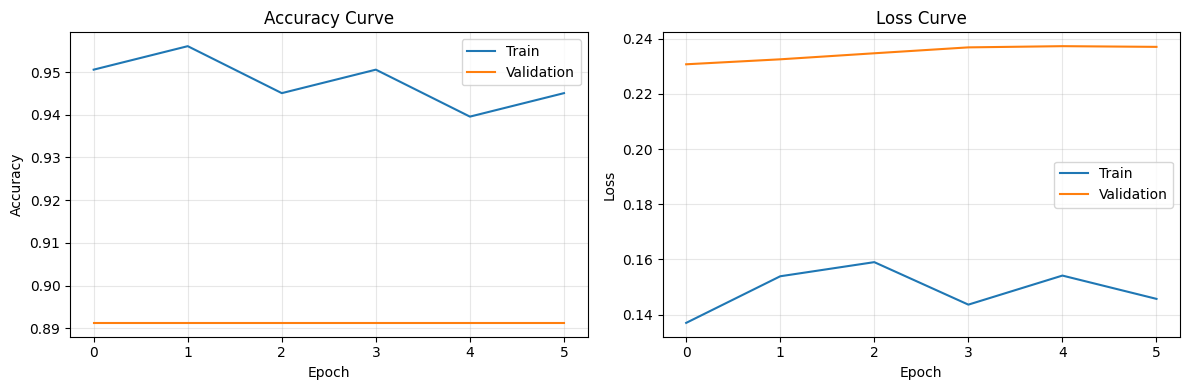

In [13]:
# ==========================================
# CELL 9 — TRAINING CURVES
# ==========================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


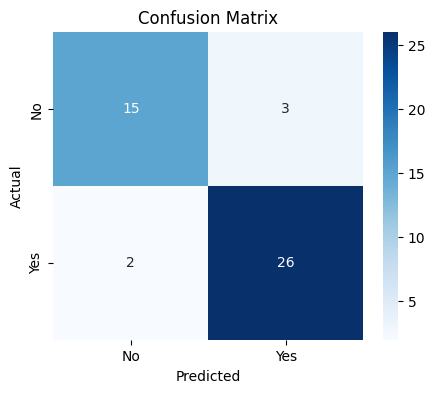


Classification Report:
              precision    recall  f1-score   support

No (Healthy)       0.88      0.83      0.86        18
 Yes (Tumor)       0.90      0.93      0.91        28

    accuracy                           0.89        46
   macro avg       0.89      0.88      0.88        46
weighted avg       0.89      0.89      0.89        46



In [14]:
# ==========================================
# CELL 10 — EVALUATION (Confusion Matrix + Report)
# ==========================================
y_pred_prob = model.predict(X_test)
y_pred      = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No (Healthy)', 'Yes (Tumor)']))